Import libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

Loading data


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.OEKHUQ_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Dataset loaded ✅
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato

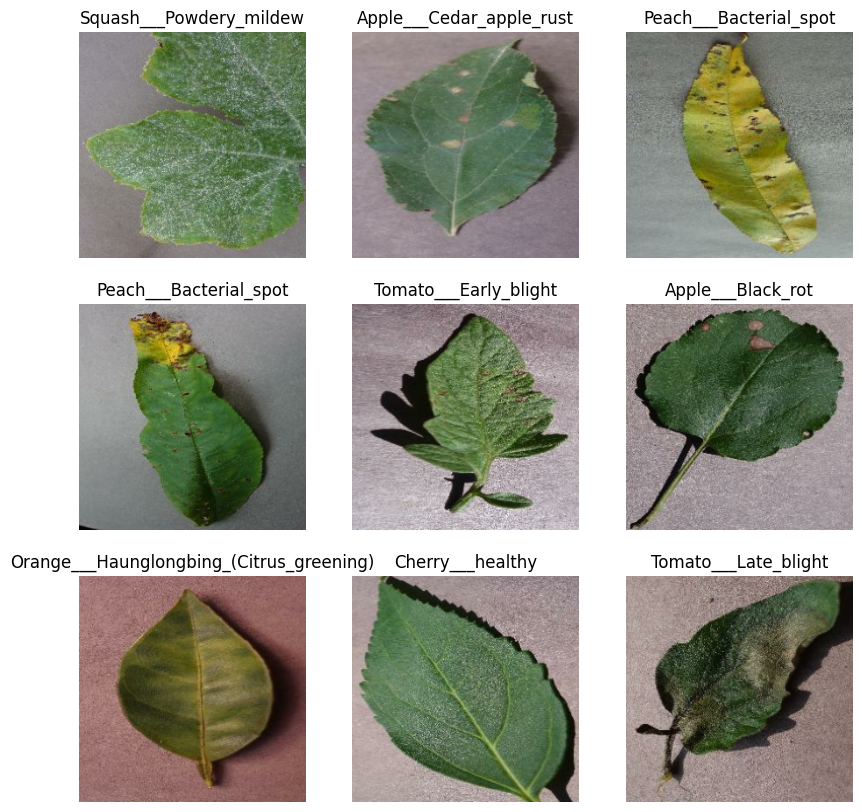

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


(train_data, val_data), dataset_info = tfds.load(
    "plant_village",
    split=["train[:80%]", "train[80%:]"],   # split into train & validation
    as_supervised=True,
    with_info=True
)

print("Dataset loaded ✅")


class_names = dataset_info.features['label'].names
print("Classes:", class_names)

#preprocessing
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_data = val_data.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#visualizing
plt.figure(figsize=(10,10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

data augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

loading pre-trained model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


building a model

In [ ]:
model = tf.keras.Sequential([
    data_augmentation,
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 117s 81ms/step - accuracy: 0.7996 - loss: 0.6900 - val_accuracy: 0.9171 - val_loss: 0.2591
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 111s 81ms/step - accuracy: 0.8701 - loss: 0.4159 - val_accuracy: 0.9309 - val_loss: 0.2233
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 111s 81ms/step - accuracy: 0.8823 - loss: 0.3706 - val_accuracy: 0.9329 - val_loss: 0.1997
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 109s 80ms/step - accuracy: 0.8909 - loss: 0.3476 - val_accuracy: 0.9318 - val_loss: 0.2053
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 76ms/step - accuracy: 0.8934 - loss: 0.3374 - val_accuracy: 0.9426 - val_loss: 0.1760
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - accuracy: 0.8968 - loss: 0.3249 - val_accuracy: 0.9392 - val_loss: 0.1850
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - accuracy: 0.9000 - loss: 0.3222 - val_accuracy: 0.9421 - val_loss: 0.1731
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - accuracy: 

Stop overfitting

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

Train with callbacks

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9101 - loss: 0.2850

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 77ms/step - accuracy: 0.9091 - loss: 0.2900 - val_accuracy: 0.9412 - val_loss: 0.1796
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 76ms/step - accuracy: 0.9058 - loss: 0.2975 - val_accuracy: 0.9409 - val_loss: 0.1792
Epoch 3/15
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9093 - loss: 0.2810

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - accuracy: 0.9079 - loss: 0.2870 - val_accuracy: 0.9418 - val_loss: 0.1849
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - accuracy: 0.9095 - loss: 0.2888 - val_accuracy: 0.9400 - val_loss: 0.1797
Epoch 5/15
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9085 - loss: 0.2836

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - accuracy: 0.9093 - loss: 0.2855 - val_accuracy: 0.9431 - val_loss: 0.1827


Graph

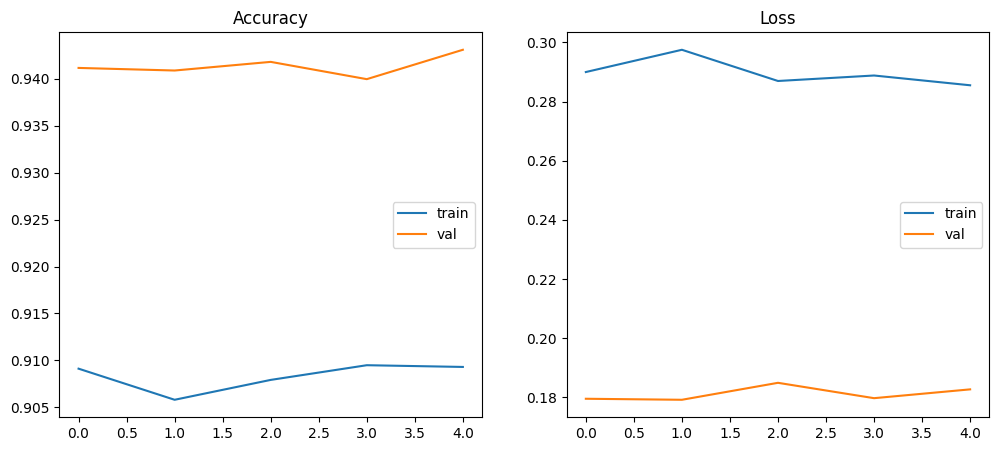

In [ ]:
plt.figure(figsize=(12,5))

# accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

fine turing & compiling

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Training the model

In [ ]:
fine_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 169s 114ms/step - accuracy: 0.8881 - loss: 0.3873 - val_accuracy: 0.9123 - val_loss: 0.4455
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 157s 115ms/step - accuracy: 0.9348 - loss: 0.2096 - val_accuracy: 0.9208 - val_loss: 0.3525
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 156s 114ms/step - accuracy: 0.9513 - loss: 0.1576 - val_accuracy: 0.9600 - val_loss: 0.1408
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 156s 114ms/step - accuracy: 0.9601 - loss: 0.1316 - val_accuracy: 0.9386 - val_loss: 0.2588
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 156s 115ms/step - accuracy: 0.9633 - loss: 0.1185 - val_accuracy: 0.9531 - val_loss: 0.1742


Evalution and Saving step

In [ ]:
loss, acc = model.evaluate(val_data)
print("Final Accuracy:", acc)

340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9531 - loss: 0.1742
Final Accuracy: 0.953135073184967


Solutions for the diseases:

In [ ]:
solutions = {
    "Tomato___Early_blight": "Use fungicide and remove infected leaves",
    "Apple___Black_rot": "Prune affected areas and apply fungicide",
    "Potato___Late_blight": "Avoid overhead watering and use resistant seeds"
}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted class: Tomato___healthy
Solution: OOPS!No solution available


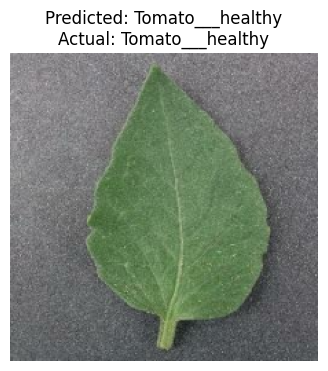

In [ ]:
# sample image from the validation data
for images, labels in val_data.take(1):
    sample_image = images[0] # Take the first image
    sample_label = labels[0] # Take the first label for comparison
    break

# Make a prediction using the trained model
# The model expects a batch of images, so we add a batch dimension to the single image
prediction_batch = model.predict(tf.expand_dims(sample_image, axis=0))
prediction = prediction_batch[0] # Extract the prediction probabilities for the single image

pred_class = class_names[np.argmax(prediction)]

print("Predicted class:", pred_class)
print("Solution:", solutions.get(pred_class, "OOPS!No solution available"))

plt.figure(figsize=(4,4))
plt.imshow(sample_image)
plt.title(f"Predicted: {pred_class}\nActual: {class_names[sample_label.numpy()]}")
plt.axis("off")
plt.show()